In [1]:
import torch
from torch import nn
import torchvision
from torchvision import datasets ,transforms
from torchvision import transforms
from torchvision.transforms import ToTensor

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32,padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914,0.4822,0.4465),
        std=(0.2470,0.2435,0.2616)
    )
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914,0.4822,0.4465),
        std=(0.2470,0.2435,0.2616)
    )
])

In [4]:
from torchvision import datasets
from torchvision.transforms import ToTensor

train_data = datasets.CIFAR10(
    root="CIFAR_data",
    train=True,
    download=False,
    transform=train_transform
)

test_data = datasets.CIFAR10(
    root="CIFAR_data",
    train=False,
    download=False,
    transform=test_transform
)

In [5]:
img , label= train_data[0]
img

tensor([[[-1.9895, -1.9895, -1.9895,  ..., -0.0843, -0.5923, -1.1798],
         [-1.9895, -1.9895, -1.9895,  ...,  0.0586, -0.2430, -0.6717],
         [-1.9895, -1.9895, -1.9895,  ..., -0.1319, -0.1636, -0.3065],
         ...,
         [-1.9895, -1.9895, -1.9895,  ...,  1.2018,  1.1541,  1.0906],
         [-1.9895, -1.9895, -1.9895,  ...,  1.4717,  1.2176,  0.9954],
         [-1.9895, -1.9895, -1.9895,  ..., -1.9895, -1.9895, -1.9895]],

        [[-1.9803, -1.9803, -1.9803,  ..., -0.6597, -1.1589, -1.5455],
         [-1.9803, -1.9803, -1.9803,  ..., -0.4986, -0.8207, -1.1750],
         [-1.9803, -1.9803, -1.9803,  ..., -0.7885, -0.8529, -0.9657],
         ...,
         [-1.9803, -1.9803, -1.9803,  ...,  0.6609,  0.5643,  0.4838],
         [-1.9803, -1.9803, -1.9803,  ...,  1.0636,  0.7254,  0.4194],
         [-1.9803, -1.9803, -1.9803,  ..., -1.9803, -1.9803, -1.9803]],

        [[-1.7068, -1.7068, -1.7068,  ..., -1.0622, -1.3920, -1.5869],
         [-1.7068, -1.7068, -1.7068,  ..., -0

In [6]:
len(train_data) , len(test_data)

(50000, 10000)

In [7]:
from torch.utils.data import DataLoader
train_data_loader = DataLoader(train_data,32)
test_data_loader = DataLoader(test_data,32)

In [8]:
t_feature_b , t_labels_b = next(iter(test_data_loader))
t_feature_b.shape

torch.Size([32, 3, 32, 32])

In [9]:
class_names = train_data.classes

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.0942786].


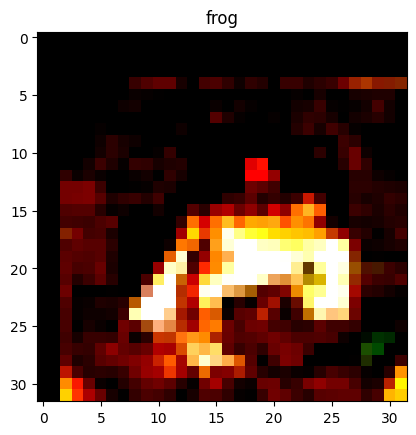

In [66]:
import matplotlib.pyplot as plt
import numpy as np
img = img.detach().squeeze().cpu().numpy()
img = np.transpose(img,(1,2,0))
plt.imshow(img)
plt.title(class_names[label])
plt.show()

In [10]:
class CIFAR10V0(nn.Module):
    def __init__(self,in_f:int,hidden:int,out_f:int):
        super().__init__()
        self.Firstlayer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features = in_f,out_features = hidden),
            nn.ReLU(),
            nn.Linear(in_features = hidden , out_features = hidden),
            nn.ReLU(),
            nn.Linear(in_features = hidden , out_features = hidden),
            nn.ReLU(),
            nn.Linear(in_features = hidden , out_features = out_f),
            nn.ReLU()
        )
    def forward(self,X:torch.Tensor):
        return self.Firstlayer(X)

In [11]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
modelV1 = CIFAR10V0(3072,10,len(class_names)).to(device)

In [12]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = modelV1.parameters(),lr=0.01)

In [10]:
from tqdm.auto import tqdm
from helper_functions import accuracy_fn
def Trainingloop(model:torch.nn.Module,
                data_loader : torch.utils.data.DataLoader,
                loss_fn : nn,
                optimizer : torch.optim,
                accuracy_fn=accuracy_fn,
                device:torch.device=device):
    train_loss = 0
    acc = 0
    for batches , (X,y) in tqdm(enumerate(data_loader)):
        X = X.to(device)
        y = y.to(device)
        y_logits = model(X)
        loss = loss_fn(y_logits,y)
        acc += accuracy_fn(y,y_logits.argmax(dim=1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss
    train_loss/=len(data_loader)
    acc/=len(data_loader)
    print(f"Train loss {train_loss} , Train Accuracy {acc}")

def Testingloop(model:torch.nn.Module,
                data_loader : torch.utils.data.DataLoader,
                loss_fn : nn,
                accuracy_fn=accuracy_fn,
                device:torch.device=device):
    test_loss = 0
    acc = 0
    for batches , (X,y) in tqdm(enumerate(data_loader)):
        X = X.to(device)
        y = y.to(device)
        y_logits = model(X)
        test_loss += loss_fn(y_logits,y)
        acc += accuracy_fn(y,y_logits.argmax(dim=1))
    test_loss/=len(data_loader)
    acc/=len(data_loader)
    print(f"Test loss {test_loss} , Test Accuracy {acc}")

C:\Users\Burhan\anaconda3\envs\ml_env\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [25]:
epoch = 5
for epoch in range(epoch):
    Trainingloop(modelV1,train_data_loader,loss_fn,optimizer)
    Testingloop(modelV1,test_data_loader,loss_fn)

0it [00:00, ?it/s]

Train loss 2.2784574031829834 , Train Accuracy 14.835252719129878


0it [00:00, ?it/s]

Test loss 2.2389914989471436 , Test Accuracy 18.96964856230032


0it [00:00, ?it/s]

...

Test loss 1.912938117980957 , Test Accuracy 32.48801916932907


0it [00:00, ?it/s]

Train loss 1.834077000617981 , Train Accuracy 34.25503838771593


0it [00:00, ?it/s]

Test loss 1.792720913887024 , Test Accuracy 35.41333865814696


In [26]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
modelV2 = CIFAR10V0(3072,20,len(class_names)).to(device)
optimizer2 = torch.optim.SGD(params = modelV2.parameters(),lr=0.01)

In [28]:
epoch = 5
for epoch in range(epoch):
    Trainingloop(modelV2,train_data_loader,loss_fn,optimizer2)
    Testingloop(modelV2,test_data_loader,loss_fn)

0it [00:00, ?it/s]

Train loss 2.2734103202819824 , Train Accuracy 16.202815099168266


0it [00:00, ?it/s]

Test loss 2.2063357830047607 , Test Accuracy 19.758386581469647


0it [00:00, ?it/s]

...

Test loss 1.9531335830688477 , Test Accuracy 34.17531948881789


0it [00:00, ?it/s]

Train loss 1.9281848669052124 , Train Accuracy 34.79886436340371


0it [00:00, ?it/s]

Test loss 1.8836652040481567 , Test Accuracy 34.76437699680511


In [35]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
modelV3 = CIFAR10V0(3072,20,len(class_names)).to(device)
optimizer = torch.optim.AdamW(params = modelV3.parameters(),lr=1e-4)

epoch = 5
for epoch in range(epoch):
    Trainingloop(modelV3,train_data_loader,loss_fn,optimizer)
    Testingloop(modelV3,test_data_loader,loss_fn)

0it [00:00, ?it/s]

Train loss 2.2405917644500732 , Train Accuracy 18.306142034548945


0it [00:00, ?it/s]

Test loss 2.197714328765869 , Test Accuracy 21.096246006389777


0it [00:00, ?it/s]

...

Test loss 2.120522975921631 , Test Accuracy 26.078274760383387


0it [00:00, ?it/s]

Train loss 2.115314483642578 , Train Accuracy 26.80542226487524


0it [00:00, ?it/s]

Test loss 2.106208324432373 , Test Accuracy 26.767172523961662


In [11]:
class CIFAR10V1(nn.Module):
    def __init__(self,in_f:int,hidden:int,out_f:int):
        super().__init__()
        self.firstblock = nn.Sequential(
            nn.Conv2d(in_channels=in_f,
                     out_channels=hidden,
                     kernel_size=3,
                     stride = 1,
                     padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden,
                      out_channels=hidden,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.secondblock = nn.Sequential(
            nn.Conv2d(in_channels=hidden,
                     out_channels=hidden,
                     kernel_size=3,
                     stride = 1,
                     padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden,
                      out_channels=hidden,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.thirdblock = nn.Sequential(
            nn.Conv2d(in_channels=hidden,
                     out_channels=hidden,
                     kernel_size=3,
                     stride = 1,
                     padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden,
                      out_channels=hidden,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.Classification = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features = hidden * 64 ,out_features = out_f)
        )

    def forward(self,X:torch.Tensor):
        #print(X.shape)
        X = self.firstblock(X)
        #print(X.shape)
        X = self.secondblock(X)
        #print(X.shape)
        #X = self.thirdblock(X)
        #print(X.shape)
        return self.Classification(X)

In [21]:
m = CIFAR10V1(3,10,len(class_names)).to(device)
y_pred = m(torch.rand([32,3,32,32]).to(device))

In [24]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
modelV4 = CIFAR10V1(3,32,len(class_names)).to(device)


In [25]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epoch = 5
for epoch in range(epoch):
    Trainingloop(modelV4,train_data_loader,loss_fn,optimizer)
    Testingloop(modelV4,test_data_loader,loss_fn)

0it [00:00, ?it/s]

Train loss 2.3032660484313965 , Train Accuracy 9.892834293026231


0it [00:00, ?it/s]

Test loss 2.3026280403137207 , Test Accuracy 10.013977635782748


0it [00:00, ?it/s]

Train loss 2.3027431964874268 , Train Accuracy 9.7228886756238


0it [00:00, ?it/s]

Test loss 2.30258846282959 , Test Accuracy 10.013977635782748


0it [00:00, ?it/s]

KeyboardInterrupt: 

In [29]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
modelV5 = CIFAR10V1(3,10,len(class_names)).to(device)
optimizer = torch.optim.SGD(params = modelV5.parameters(),lr=0.01)
epoch = 5
for epoch in range(epoch):
    Trainingloop(modelV5,train_data_loader,loss_fn,optimizer)
    Testingloop(modelV5,test_data_loader,loss_fn)

0it [00:00, ?it/s]

Train loss 2.301643133163452 , Train Accuracy 10.894513755598208


0it [00:00, ?it/s]

Test loss 2.294367551803589 , Test Accuracy 15.0758785942492


0it [00:00, ?it/s]

...

Test loss 1.5833874940872192 , Test Accuracy 43.08107028753994


0it [00:00, ?it/s]

Train loss 1.5120004415512085 , Train Accuracy 46.11324376199616


0it [00:00, ?it/s]

Test loss 1.51249361038208 , Test Accuracy 46.246006389776355


In [30]:
epoch = 25
for epoch in range(epoch):
    Trainingloop(modelV5,train_data_loader,loss_fn,optimizer)
    Testingloop(modelV5,test_data_loader,loss_fn)

0it [00:00, ?it/s]

Train loss 1.4496865272521973 , Train Accuracy 48.15858925143954


0it [00:00, ?it/s]

Test loss 1.4511040449142456 , Test Accuracy 48.043130990415335


0it [00:00, ?it/s]

...

Train loss 0.9949936270713806 , Train Accuracy 65.045185540627


0it [00:00, ?it/s]

Test loss 1.0591111183166504 , Test Accuracy 63.188897763578275


0it [00:00, ?it/s]

KeyboardInterrupt: 

In [11]:
class CIFAR10V2(nn.Module):
    def __init__(self, out_f:int):
        super().__init__()
        self.firstblock = nn.Sequential(
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=32,
                out_channels=32,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2)
        )

        self.secondblock = nn.Sequential(
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(
                in_channels=64,
                out_channels=64,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2)
        )

        self.thirdblock = nn.Sequential(
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),

            nn.Conv2d(
                in_channels=128,
                out_channels=128,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2)
        )

        self.Classification = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                in_features=2048*2,
                out_features=out_f
            )
        )
    def forward(self, X):
        X = self.firstblock(X)
        X = self.secondblock(X)
        return self.Classification(X)

    def init_wight(m):
        if isinstance(m,nn.Conv2d):
            nn.init.kaiming_normal_(
                m.weight,
                mode='fan_out',
                nonlinearity='relu'
            )
            if m.bias is not None:
                nn.init.consatant_(m.bias,0)

In [46]:
m = CIFAR10V2(len(class_names)).to(device)
y_pred = m(torch.rand([32,3,32,32]).to(device))

In [67]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
modelV6 = CIFAR10V2(len(class_names)).to(device)
optimizer = torch.optim.Adam(params=modelV6.parameters(),lr=1e-3,weight_decay=1e-4)
epoch = 5
for epoch in range(epoch):
    Trainingloop(modelV6,train_data_loader,loss_fn,optimizer)
    Testingloop(modelV6,test_data_loader,loss_fn)

0it [00:00, ?it/s]

Train loss 1.4544252157211304 , Train Accuracy 48.142594369801664


0it [00:00, ?it/s]

Test loss 1.0785948038101196 , Test Accuracy 61.60143769968051


0it [00:00, ?it/s]

...

Test loss 0.7545164227485657 , Test Accuracy 74.01158146964856


0it [00:00, ?it/s]

Train loss 0.7302892208099365 , Train Accuracy 74.68610044785669


0it [00:00, ?it/s]

Test loss 0.721491277217865 , Test Accuracy 75.46924920127796


In [68]:
epoch = 3
for epoch in range(epoch):
    Trainingloop(modelV6,train_data_loader,loss_fn,optimizer)
    Testingloop(modelV6,test_data_loader,loss_fn)

0it [00:00, ?it/s]

Train loss 0.6887952089309692 , Train Accuracy 76.08165387076136


0it [00:00, ?it/s]

Test loss 0.6985219717025757 , Test Accuracy 76.39776357827476


0it [00:00, ?it/s]

...

Test loss 0.6519293189048767 , Test Accuracy 78.37460063897764


0it [00:00, ?it/s]

Train loss 0.6227189898490906 , Train Accuracy 78.36492322456814


0it [00:00, ?it/s]

Test loss 0.6623188257217407 , Test Accuracy 77.96525559105432


In [69]:
epoch = 3
for epoch in range(epoch):
    Trainingloop(modelV6,train_data_loader,loss_fn,optimizer)
    Testingloop(modelV6,test_data_loader,loss_fn)

0it [00:00, ?it/s]

Train loss 0.6016715168952942 , Train Accuracy 79.16066858605247


0it [00:00, ?it/s]

Test loss 0.6377270817756653 , Test Accuracy 78.77396166134186


0it [00:00, ?it/s]

...

Test loss 0.6316220164299011 , Test Accuracy 79.07348242811501


0it [00:00, ?it/s]

Train loss 0.5612987279891968 , Train Accuracy 80.68418106206015


0it [00:00, ?it/s]

Test loss 0.6190069913864136 , Test Accuracy 79.4229233226837


In [18]:
optimizer = torch.optim.Adam(params=modelV6.parameters(),lr=1e-3,weight_decay=1e-5)
epoch = 5
for epoch in range(epoch):
    Trainingloop(modelV6,train_data_loader,loss_fn,optimizer)
    Testingloop(modelV6,test_data_loader,loss_fn)

0it [00:00, ?it/s]

Train loss 0.5185415744781494 , Train Accuracy 82.12971849008318


0it [00:00, ?it/s]

Test loss 0.5747214555740356 , Test Accuracy 81.08027156549521


0it [00:00, ?it/s]

...

Test loss 0.5583822131156921 , Test Accuracy 81.37979233226837


0it [00:00, ?it/s]

Train loss 0.48389723896980286 , Train Accuracy 83.33933141394753


0it [00:00, ?it/s]

Test loss 0.5753163695335388 , Test Accuracy 80.63099041533546


In [14]:
loss_fn = nn.CrossEntropyLoss()
Testingloop(modelV6,test_data_loader,loss_fn)

0it [00:00, ?it/s]

Test loss 0.57570481300354 , Test Accuracy 80.80071884984025


In [71]:
from pathlib import Path

model_Cifar = Path("models")
model_Cifar.mkdir(parents=True,exist_ok=True)
model_n="CNN_CIFAR10.pth"
model_s = model_Cifar/model_n
torch.save(obj=modelV6.state_dict(),f=model_s)

In [12]:
modelV6 = CIFAR10V2(len(class_names)).to(device)

In [13]:
from pathlib import Path

model_Cifar = Path("models")
model_Cifar.mkdir(parents=True,exist_ok=True)
model_n="CNN_CIFAR10.pth"
model_s = model_Cifar/model_n
modelV6.load_state_dict(torch.load(f=model_s))

C:\Users\Burhan\AppData\Local\Temp\ipykernel_21188\3502210877.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  modelV6.load_state_dict(torch.load(f=model_s))


<All keys matched successfully>

In [ ]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

confmat = ConfusionMatrix(num_classes = len(class_name), task="multiclass")
confmat_tensor = confmat(preds  = y_pred_tensor,
                        target = test_data.targets)

fig , ax = plot_confusion_matrix(
    conf_mat = confmat_tensor.numpy(),
    class_names = class_name,
    figsize=(10,7)
)